In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import warnings
import pickle
import pandas as pd
import random
import numpy as np
from tqdm.auto import tqdm
from scipy.special import xlogy
import networkx as nx
import GCRCatalogs
import healpy as hp
from GCR import GCRQuery
import matplotlib.pyplot as plt

In [4]:
sys.path.append('../')

In [5]:
import friendly.ellipses as ellipses
import friendly.entropy as entropy
import friendly.gaussians as gaussians
import friendly.graphs as graphs
import friendly.matching as matching

In [6]:
warnings.filterwarnings('ignore')

### 1. Load cosmoDC2 and DC2object with few cuts

In [7]:
tract = 4026

In [8]:
quantities_true = ['ra', 'dec', 'mag_i', 'size_true', 'size_minor_true', 'position_angle_true']

quantities_obj = ['ra', 'dec', 'blendedness', 'mag_i_cModel', 'x', 'y', 'Ixx_pixel_i', 'Iyy_pixel_i', 'Ixy_pixel_i', 'patch', 'psf_fwhm_i']

In [9]:
filters_true = [(np.isfinite, 'mag_i'), 'mag_i>18', 'mag_i<29', (np.isfinite,'ellipticity_1_true'), (np.isfinite,'ellipticity_2_true'), 
                (np.isfinite,'redshift'), (np.isfinite, 'convergence'), (np.isfinite, 'mag_i'), (np.isfinite, 'shear_1'),
                (np.isfinite, 'shear_2')]

filters_obj = [(np.isfinite, 'mag_i_cModel'), 'mag_i_cModel > 18', 'mag_i_cModel < 26.5', (np.isfinite, 'mag_i_cModel'), 
               (np.isfinite,'ext_shapeHSM_HsmShapeRegauss_e1'), (np.isfinite,'ext_shapeHSM_HsmShapeRegauss_e2'), 
               (np.isfinite, 'ext_shapeHSM_HsmShapeRegauss_sigma'), ('ext_shapeHSM_HsmShapeRegauss_flag == 0'),
               (np.isfinite, 'photoz_mean'), (np.isfinite, 'blendedness')]

In [10]:
cosmodc2 = GCRCatalogs.load_catalog('cosmoDC2_v1.1.4_image') #truth catalog
dc2 = GCRCatalogs.load_catalog('dc2_object_run2.2i_dr6_with_addons') #object catalog

In [11]:
object_data = pd.DataFrame(dc2.get_quantities(quantities_obj,
                                  filters=['extendedness>0', 'clean']+filters_obj,
                                  native_filters=[f'tract=={tract}']))

In [12]:
eps = 10/3600 # 10 arcsec
max_ra = np.nanmax(object_data['ra']) + eps
min_ra = np.nanmin(object_data['ra']) - eps
max_dec = np.nanmax(object_data['dec']) + eps
min_dec = np.nanmin(object_data['dec']) - eps
pos_filters = [f'ra >= {min_ra}',f'ra <= {max_ra}', f'dec >= {min_dec}', f'dec <= {max_dec}']

vertices = hp.ang2vec(np.array([min_ra, max_ra, max_ra, min_ra]),
                      np.array([min_dec, min_dec, max_dec, max_dec]), lonlat=True)
ipix = hp.query_polygon(32, vertices, inclusive=True)
healpix_filter = GCRQuery((lambda h: np.isin(h, ipix, True), "healpix_pixel"))

In [13]:
truth_data = pd.DataFrame(cosmodc2.get_quantities(quantities_true, filters=filters_true+pos_filters, 
                                      native_filters=healpix_filter))

In [14]:
print("number of galaxies =", len(truth_data['ra']))
print("number of objects =", len(object_data['ra']))

number of galaxies = 5155624
number of objects = 636819


### 2. Friends-of-Friends groups with linking length = 2''

In [15]:
# need 'ra', 'dec'
FoF_groups = matching.FoF_matching(truth_data, object_data, 2.) #takes time

In [17]:
FoF_groups[:10]

[[[0, 2356171, 2400185], [269269]],
 [[2, 1506180, 1506193, 3968597, 4089968, 4217527], [268975, 268976]],
 [[3, 1505921], []],
 [[4], [269513]],
 [[5, 1506017, 1506228], [269167]],
 [[6, 3952262, 4202739], []],
 [[8, 82, 198, 1505960, 1505967, 1506081, 1506083, 1506175, 3937130, 3937293],
  [269345, 269346]],
 [[12, 16, 1506294, 3937291], []],
 [[18, 191, 1506194, 4252726], []],
 [[19, 216, 1506016], [269347]]]

### 3. Select one random group

In [141]:
group = [[],[]]
n = 2 #number of galaxies
m = 1 #number of objects

while (len(group[0]) != n) | (len(group[1]) != m): #choose which system you want to study
    group = FoF_groups[random.randint(0,len(FoF_groups))]

print(group)

[[588884, 2930505], [156135]]


### 4. Object ellipse parameters

In [142]:
# need 'x', 'y', 'Ixx_pixel_i', 'Iyy_pixel_i', 'Ixy_pixel_i'
obj_infos = ellipses.ellipse_infos(group, truth_data, object_data, dc2_type='object')

In [143]:
obj_infos

,x,y,a,b,theta
156135,6105.675857,22425.573905,2.652636,2.196853,158.339328


In [144]:
obj_param = ellipses.ellipse_parameters(obj_infos)

In [145]:
obj_param

,A,B,C,D,E,F
156135,5.127299,6.735343,0.758238,-48309.541449,-155673.490259,3.786030e+09


### 5. Galaxy ellipse parameters

In [146]:
# need 'psf_fwhm_i', 'size_true', 'size_minor_true', 'position_angle_true', 'ra', 'dec'
gal_infos = ellipses.ellipse_infos(group, truth_data, object_data, dc2_type='galaxy')

In [147]:
gal_infos

,x,y,a,b,theta
588884,6101.683525,22425.887848,2.535529,2.501494,109.020772
2930505,6105.736878,22425.448439,2.824353,2.590609,141.962076


In [148]:
gal_param = ellipses.ellipse_parameters(gal_infos)

#### Plot the ellipses

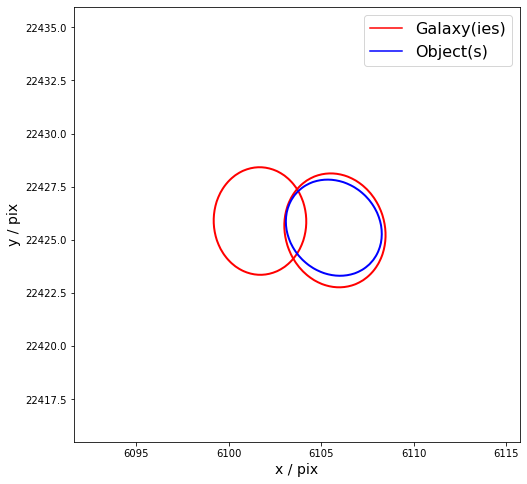

In [149]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111)

rough_size = 4 * np.sqrt(gal_infos['a'][group[0][0]] * gal_infos['b'][group[0][0]])
idx1 = group[0]
idx2 = group[1]

for n in range(len(idx1)):
    p_gal = [gal_param[k][idx1[n]] for k in gal_param.keys()]
    ellipses.plot_shape(gal_infos['x'][idx1[n]], gal_infos['y'][idx1[n]], rough_size, p_gal, c='r', ls='-', ax=ax)    

for m in range(len(idx2)):
    p_obj = [obj_param[k][idx2[m]] for k in obj_param.keys()]
    ellipses.plot_shape(obj_infos['x'][idx2[m]], obj_infos['y'][idx2[m]], rough_size, p_obj, c='b', ls='-', ax=ax)

ax.set_xlabel('x / pix', fontsize=14)
ax.set_ylabel('y / pix', fontsize=14)

ax.plot([], [], 'r', label='Galaxy(ies)')
ax.plot([], [], 'b', label='Object(s)')
ax.legend(prop={'size':16})

### 6. NetworkX graph

In [150]:
infos = pd.merge(gal_infos.T, obj_infos.T, how='outer', left_index=True, right_index=True)

In [151]:
infos

,588884,2930505,156135
x,6101.683525,6105.736878,6105.675857
y,22425.887848,22425.448439,22425.573905
a,2.535529,2.824353,2.652636
b,2.501494,2.590609,2.196853
theta,109.020772,141.962076,158.339328


In [152]:
param = pd.merge(gal_param.T, obj_param.T, how='outer', left_index=True, right_index=True)

In [153]:
param

,588884,2930505,156135
A,6.410697e+00,7.191825e+00,5.127299e+00
B,6.275680e+00,7.496403e+00,6.735343e+00
C,5.282233e-02,6.142621e-01,7.582376e-01
D,-4.030063e+04,-5.768649e+04,-4.830954e+04
E,-1.410600e+05,-1.718607e+05,-1.556735e+05
F,3.409298e+09,4.206272e+09,3.786030e+09


In [154]:
G = graphs.NetworkX_graph(group, truth_data, object_data, infos, param)

In [155]:
list(G.nodes(data=True))

[(588884,
  {'galaxy': True,
   'magnitude': 26.850701313633074,
   'purity': 0.5524705851503612}),
 (2930505,
  {'galaxy': True,
   'magnitude': 24.243778358485283,
   'purity': 0.5169374479985748}),
 (156135,
  {'galaxy': False,
   'magnitude': 24.357988297615023,
   'blendedness': 0.094112469974312,
   'purity': 1.0})]

In [156]:
list(G.edges(data=True))

[(588884, 2930505, {'overlap_fraction': 0.06454816285998013}),
 (588884, 156135, {'overlap_fraction': 0.062291434927697446}),
 (2930505, 156135, {'overlap_fraction': 0.7954939341421144})]

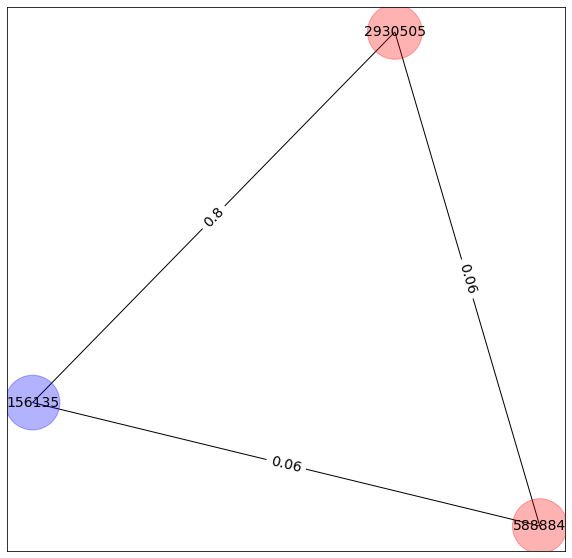

In [157]:
fig = plt.figure(figsize=(10,10))

pos = nx.spring_layout(G, seed=10, weight='overlap')
color_map = ['red' if G.nodes[k]['galaxy'] == True else 'blue' for k in list(G.nodes)]  

nx.draw_networkx_nodes(G, pos, node_color=color_map, node_size=3000, node_shape='o', alpha=0.3)
nx.draw_networkx_edges(G, pos)

nx.draw_networkx_labels(G, pos, font_size=14, font_weight='normal')
edge_labels = nx.get_edge_attributes(G, "overlap_fraction")
for k in edge_labels.keys():
    edge_labels[k] = round(edge_labels[k], 2)
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=14)
plt.show()

### 7. Cut groups if there are subgroups of ellipses

In [158]:
S = graphs.refine_groups(G)

### 8. Add probability of matching and blending entropy

In [159]:
for s in S:
    entropy.blending_entropy(s)

In [160]:
for s in S:
    obj_nodes = [i for i in s if s.nodes[i]['galaxy']==False]
    for m in obj_nodes:
        print(s.nodes[m]['blending_entropy'])

0.042724858956380236
